In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm

from ocab.guadiana import get_timeseries

In [2]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

## Configuration

In [3]:
# path where the data is stored
path_chg = Path('/home/casadoj/Data/Guadiana')

# paths where results will be saved
path_results = path_chg / 'processed'
path_gis = path_results / 'GIS'
path_ts = path_results / 'timeseries'
for path in [path_gis, path_ts]:
    path.mkdir(parents=True, exist_ok=True)

## Import data

### Gauging stations

In [4]:
# get streamflow time series
streamflow = get_timeseries(path_chg / 'raw' / 'nivel_caudal_aforos_desde_oct2021.csv')

  0%|          | 0/82 [00:00<?, ?it/s]

NameError: name 'ts' is not defined

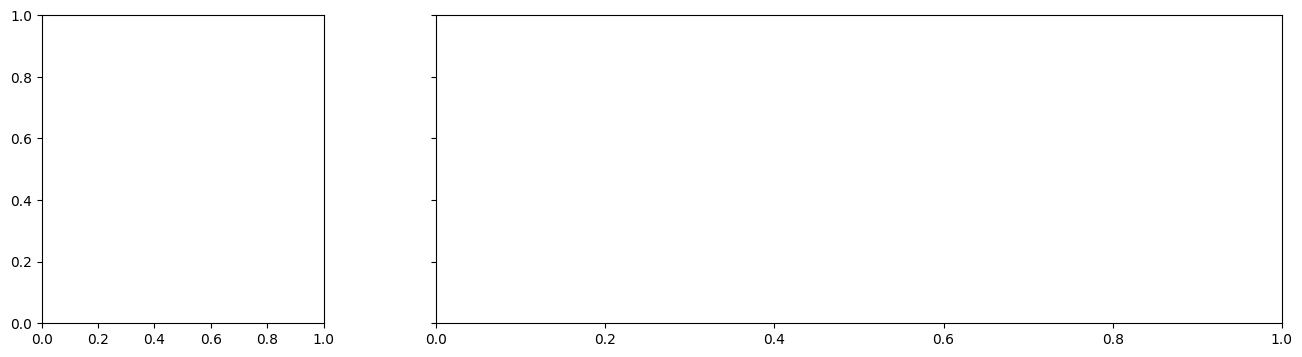

In [5]:
s = 4

fig, ax = plt.subplots(figsize=(16, 4), ncols=2, sharey=True, width_ratios=[1, 3])

# rating curve
ax[0].scatter(ts['NR1'], ts['QR1'], c=ts.index, s=s, cmap='Blues')
# ax[0].scatter(ts['NR1'], ts['QR2'], c=ts.index, s=s, cmap='Reds')
ax[0].scatter(ts['NR1'], ts['QR3'], c=ts.index, s=s, cmap='Greens')

# time series
ax[1].scatter(ts.index, ts['QR1'], c=ts.index, s=s, cmap='Blues')
# ax[1].scatter(ts.index, ts['QR2'], c=ts.index, s=s, cmap='Reds')
ax[1].scatter(ts.index, ts['QR3'], c=ts.index, s=s, cmap='Greens')

plt.show()

### Reservoirs

In [6]:
# get level-storage time series
storage = get_timeseries(path_chg / 'raw' / 'nivel_volumen_embalses_desde_oct2021.csv')

  0%|          | 0/37 [00:00<?, ?it/s]

In [7]:
# get river outflow time series
outflow = get_timeseries(path_chg / 'raw' / 'caudal_salida_rio_embalses_desde_oct2021.csv')

  0%|          | 0/26 [00:00<?, ?it/s]

In [8]:
# combine time series into a single dataframe per reservoir
IDs = set(list(storage) + list(outflow))
resops = {}
for ID in tqdm(IDs):
    if ID in storage and ID in outflow:
        resops[ID] = pd.concat([storage[ID], outflow[ID]], axis=1, join='outer')
    elif ID in storage and ID not in outflow:
        resops[ID] = storage[ID]
    elif ID not in storage and ID in outflow:
        resops[ID] = outflow[ID]

  0%|          | 0/37 [00:00<?, ?it/s]

In [15]:
reservoirs.shape

(37, 8)

In [13]:
for ID in resops.keys():
    print(ID)

E2-17
E2-13
E2-09
E2-35
E1-03
E2-18
E2-24
E2-31
E2-33
E1-05
E2-21
E2-28
E2-34
E2-07
E2-10
E2-32
E1-04
E1-06
E1-01
E2-15
E2-12
E2-11
E2-06
E2-20
E2-08
E2-01
E2-22
E2-03
E2-40
E1-09
E1-10
E2-19
E1-02
E1-08
E2-04
E1-07
E2-16


### Time series

#### Stations

In [ ]:
path = path_ts / 'stations'
path.mkdir(exist_ok=True)
for ID, ts in streamflow.items():
    ts.to_parquet(path / f'{ID}.parquet')

#### Reservoirs

In [11]:
path = path_ts / 'reservoirs'
path.mkdir(exist_ok=True)
for ID, ts in resops.items():
    ts.to_parquet(path / f'{ID}.parquet')

### Attributes

In [23]:
metadata_file = path_chg / 'raw' / 'metadatos_guadiana.xlsx'

# create table of attributes for reservoirs
stations = pd.DataFrame(columns=['ID_SAIH', 'ID_ROEA', 'Nombre', 'X_ETRS89', 'Y_ETRS89', 'Altitud', 'Cuenca_km2'])
stations['ID_SAIH'] = streamflow.keys()

# create table of attributes for reservoirs
reservoirs = pd.DataFrame(columns=['ID_SAIH', 'ID_ROEA', 'Nombre', 'X_ETRS89', 'Y_ETRS89', 'Altitud', 'Capacidad_hm3', 'Cuenca_km2'])
reservoirs['ID_SAIH'] = resops.keys()
    
with pd.ExcelWriter(metadata_file, engine='openpyxl') as writer:
    stations.to_excel(writer, sheet_name='aforos', index=False)
    reservoirs.to_excel(writer, sheet_name='embalses', index=False)